# Transformer_Toy — Edgar Allan Poe Python Shakedown

This notebook exercises the complete Python API over the native C++/CUDA implementation:

- BPE tokenizer persistence
- full-corpus-equivalent training batches
- configurable Transformer construction
- Adam optimization
- CPU/CUDA selection
- validation
- cosine learning-rate decay
- early stopping
- periodic and best checkpoints
- generation snapshots every five epochs
- final best-checkpoint generation

The default run mirrors the native shakedown: **25 epochs**, logging every **100 steps**, generation every **5 epochs**, and approximately one corpus worth of training tokens per epoch.

## 1. Environment

Run from the repository root with `.venv` active. Build the extension first:

```powershell
cmake --build build --config Release --target _transformer_toy
$env:PYTHONPATH = "$PWD\python"
```

In [1]:
from __future__ import annotations

from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import transformer_toy as tt

print("CUDA available:", tt.cuda_available())

CUDA available: True


## 2. Configuration

In [5]:
PROJECT_ROOT = Path.cwd()
CORPUS_PATH = PROJECT_ROOT / "data" / "poe" / "edgar_allan_poe_corpus.txt"

ARTIFACT_ROOT = PROJECT_ROOT / "python_shakedown_artifacts" / "eap_bpe_512"
TOKENIZER_PATH = ARTIFACT_ROOT / "tokenizers" / "eap_bpe_512.bin"
CHECKPOINT_DIR = ARTIFACT_ROOT / "checkpoints"

TOKENIZER_PATH.parent.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DATA_SEED = 2026
MODEL_SEED = 1234
GENERATION_SEED = 4321

CONTEXT_LENGTH = 64
BATCH_SIZE = 16
EPOCHS = 25

D_MODEL = 128
D_FF = 512
NUM_LAYERS = 4
NUM_HEADS = 4

INITIAL_LEARNING_RATE = 1.0e-3
MINIMUM_LEARNING_RATE = 1.0e-5
WEIGHT_DECAY = 0.0

VALIDATION_FRACTION = 0.10
LOG_EVERY_STEPS = 100
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1.0e-4
CHECKPOINT_EVERY_EPOCHS = 5
GENERATION_EVERY_EPOCHS = 5

GENERATION_PROMPT = "Once upon"
GENERATION_MAX_NEW_TOKENS = 300
GENERATION_TEMPERATURE = 0.8
GENERATION_TOP_K = 40

DEVICE = tt.Device.CUDA if tt.cuda_available() else tt.Device.CPU

print("Device:", DEVICE)
print("Corpus:", CORPUS_PATH)
print("Artifacts:", ARTIFACT_ROOT)

Device: Device.CUDA
Corpus: c:\Users\Alexander\OneDrive\Transformers_Toy\data\poe\edgar_allan_poe_corpus.txt
Artifacts: c:\Users\Alexander\OneDrive\Transformers_Toy\python_shakedown_artifacts\eap_bpe_512


## 3. Split the corpus

In [6]:
if not CORPUS_PATH.exists():
    raise FileNotFoundError(
        f"Corpus not found: {CORPUS_PATH}\n"
        "Update CORPUS_PATH in the configuration cell."
    )

raw_text = CORPUS_PATH.read_text(encoding="utf-8")
split_index = int(len(raw_text) * (1.0 - VALIDATION_FRACTION))

newline_index = raw_text.find("\n", split_index)
if newline_index != -1:
    split_index = newline_index + 1

train_text = raw_text[:split_index]
validation_text = raw_text[split_index:]

TRAIN_CORPUS_PATH = ARTIFACT_ROOT / "eap_train.txt"
VALIDATION_CORPUS_PATH = ARTIFACT_ROOT / "eap_validation.txt"

with TRAIN_CORPUS_PATH.open("w", encoding="utf-8", newline="\n") as file:
    file.write(train_text)

with VALIDATION_CORPUS_PATH.open("w", encoding="utf-8", newline="\n") as file:
    file.write(validation_text)

print(f"Total characters:      {len(raw_text):,}")
print(f"Training characters:   {len(train_text):,}")
print(f"Validation characters: {len(validation_text):,}")

Total characters:      1,907,183
Training characters:   1,748,150
Validation characters: 159,033


## 4. Build shared BPE tokenizer and datasets

In [7]:
train_tokenizer_config = tt.TokenizerConfig()
train_tokenizer_config.type = tt.TokenizerType.BPE
train_tokenizer_config.vocab_size = 512
train_tokenizer_config.min_frequency = 2
train_tokenizer_config.model_path = str(TOKENIZER_PATH)
train_tokenizer_config.train_if_missing = True
train_tokenizer_config.preserve_whitespace = True
train_tokenizer_config.preserve_punctuation = True

train_dataset = tt.TextDataset(
    file_path=str(TRAIN_CORPUS_PATH),
    context_length=CONTEXT_LENGTH,
    tokenizer_config=train_tokenizer_config,
)

validation_tokenizer_config = tt.TokenizerConfig()
validation_tokenizer_config.type = tt.TokenizerType.BPE
validation_tokenizer_config.vocab_size = 512
validation_tokenizer_config.min_frequency = 2
validation_tokenizer_config.model_path = str(TOKENIZER_PATH)
validation_tokenizer_config.train_if_missing = False
validation_tokenizer_config.preserve_whitespace = True
validation_tokenizer_config.preserve_punctuation = True

validation_dataset = tt.TextDataset(
    file_path=str(VALIDATION_CORPUS_PATH),
    context_length=CONTEXT_LENGTH,
    tokenizer_config=validation_tokenizer_config,
)

if train_dataset.vocab_size != validation_dataset.vocab_size:
    raise RuntimeError("Training and validation vocabularies differ.")

tokenizer = train_dataset.tokenizer

print(train_dataset)
print(validation_dataset)
print("Tokenizer:", tokenizer.name())
print("Vocabulary size:", train_dataset.vocab_size)

TextDataset(token_count=750065, context_length=64, num_windows=750001, vocab_size=512)
TextDataset(token_count=67787, context_length=64, num_windows=67723, vocab_size=512)
Tokenizer: bpe
Vocabulary size: 512


## 5. Materialize full-corpus-equivalent batches

In [8]:
def materialize_batches(
    dataset: tt.TextDataset,
    *,
    batch_size: int,
    seed: int,
) -> list[tt.TrainingBatch]:
    tokens_per_step = batch_size * dataset.context_length
    step_count = max(1, dataset.token_count // tokens_per_step)

    rng = tt.Random(seed)
    batches = []

    for _ in range(step_count):
        inputs, targets = dataset.get_batch(batch_size, rng)
        batches.append(tt.TrainingBatch(inputs=inputs, targets=targets))

    return batches


start = time.perf_counter()

train_batches = materialize_batches(
    train_dataset,
    batch_size=BATCH_SIZE,
    seed=DATA_SEED,
)

validation_batches = materialize_batches(
    validation_dataset,
    batch_size=BATCH_SIZE,
    seed=DATA_SEED + 1,
)

elapsed = time.perf_counter() - start

print(f"Training batches/epoch:  {len(train_batches):,}")
print(f"Validation batches/pass: {len(validation_batches):,}")
print(f"Training tokens/epoch:   {len(train_batches) * BATCH_SIZE * CONTEXT_LENGTH:,}")
print(f"Batch materialization:   {elapsed:.2f} seconds")

Training batches/epoch:  732
Validation batches/pass: 66
Training tokens/epoch:   749,568
Batch materialization:   0.07 seconds


## 6. Construct the Transformer

In [9]:
block_config = tt.TransformerBlockConfig(
    d_model=D_MODEL,
    d_ff=D_FF,
    residual_dropout=0.0,
    ffn_dropout=0.0,
    pre_norm=True,
    use_bias=True,
)
block_config.attention_type = tt.AttentionType.MULTI_HEAD
block_config.num_heads = NUM_HEADS
block_config.validate()

model_config = tt.TransformerModelConfig(
    vocab_size=train_dataset.vocab_size,
    max_seq_len=CONTEXT_LENGTH,
    num_layers=NUM_LAYERS,
    block=block_config,
    learned_positional_embeddings=True,
    embedding_dropout=0.0,
)
model_config.validate()

model = tt.Transformer(
    config=model_config,
    rng=tt.Random(MODEL_SEED),
)

parameter_count = sum(parameter.size for parameter in model.parameters())

print(model)
print("Parameter tensors:", len(model.parameters()))
print(f"Scalar parameters: {parameter_count:,}")

Transformer(parameters=70)
Parameter tensors: 70
Scalar parameters: 933,120


## 7. Configure training and callbacks

In [10]:
loss_function = tt.CrossEntropyLoss()

optimizer = tt.AdamOptimizer(
    learning_rate=INITIAL_LEARNING_RATE,
    beta1=0.9,
    beta2=0.999,
    epsilon=1.0e-8,
    weight_decay=WEIGHT_DECAY,
)

training_config = tt.TrainingConfig()
training_config.epochs = EPOCHS
training_config.batch_size = BATCH_SIZE
training_config.device = DEVICE
training_config.log_every_steps = LOG_EVERY_STEPS
training_config.run_name = "eap_bpe_512_python_shakedown"
training_config.checkpoint_directory = str(CHECKPOINT_DIR)
training_config.enable_profiling = True
training_config.print_profile_summary = True
training_config.synchronize_profiling_phases = False
training_config.validate()

generation_config = tt.GenerationConfig()
generation_config.max_new_tokens = GENERATION_MAX_NEW_TOKENS
generation_config.temperature = GENERATION_TEMPERATURE
generation_config.top_k = min(GENERATION_TOP_K, train_dataset.vocab_size)
generation_config.greedy_sampling = False
generation_config.print_generated_text = True
generation_config.print_token_ids = False
generation_config.random_seed = GENERATION_SEED
generation_config.validate()

trainer = tt.Trainer(
    model=model,
    loss_function=loss_function,
    optimizer=optimizer,
    config=training_config,
)

periodic_checkpoint = tt.CheckpointCallback(
    checkpoint_directory=str(CHECKPOINT_DIR),
    every_n_epochs=CHECKPOINT_EVERY_EPOCHS,
)

best_checkpoint = tt.BestCheckpointCallback(
    checkpoint_directory=str(CHECKPOINT_DIR),
    min_delta=EARLY_STOPPING_MIN_DELTA,
    prefer_validation_loss=True,
)

early_stopping = tt.EarlyStoppingCallback(
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
    prefer_validation_loss=True,
)

lr_scheduler = tt.LearningRateSchedulerCallback(
    schedule=tt.LearningRateSchedule.COSINE_DECAY,
    step_size=1,
    gamma=1.0,
    minimum_learning_rate=MINIMUM_LEARNING_RATE,
)

generation_callback = tt.GenerationCallback(
    tokenizer=tokenizer,
    prompt=GENERATION_PROMPT,
    generation_config=generation_config,
    every_n_epochs=GENERATION_EVERY_EPOCHS,
    print_generated_text=True,
    random_seed=GENERATION_SEED,
)

trainer.add_callback(periodic_checkpoint)
trainer.add_callback(best_checkpoint)
trainer.add_callback(early_stopping)
trainer.add_callback(lr_scheduler)
trainer.add_callback(generation_callback)

## 8. Run the 25-epoch shakedown

In [11]:
training_start = time.perf_counter()

trainer.train(
    train_batches=train_batches,
    validation_batches=validation_batches,
)

training_elapsed = time.perf_counter() - training_start
history = trainer.history
completed_epochs = history.validation_count

print("\n" + "=" * 60)
print("Python Shakedown Results")
print("=" * 60)
print("Device:", DEVICE)
print("Completed epochs:", completed_epochs)
print("Training steps:", history.train_count)
print(f"Elapsed seconds: {training_elapsed:.3f}")
print(f"Seconds per epoch: {training_elapsed / max(1, completed_epochs):.3f}")
print("Initial training loss:", history.train_losses[0])
print("Final training loss:", history.train_losses[-1])
print("Initial validation loss:", history.validation_losses[0])
print("Final validation loss:", history.validation_losses[-1])
print("Initial learning rate:", lr_scheduler.initial_learning_rate)
print("Final learning rate:", lr_scheduler.current_learning_rate)
print("Best checkpoint epoch:", best_checkpoint.best_epoch)
print("Best checkpoint path:", best_checkpoint.best_checkpoint_path)
print("=" * 60)


Python Shakedown Results
Device: Device.CUDA
Completed epochs: 12
Training steps: 8784
Elapsed seconds: 2663.035
Seconds per epoch: 221.920
Initial training loss: 6.475601673126221
Final training loss: 2.5155975818634033
Initial validation loss: 4.401352405548096
Final validation loss: 3.6964004039764404
Initial learning rate: 0.0010000000474974513
Final learning rate: 0.0005360813811421394
Best checkpoint epoch: 7
Best checkpoint path: c:\Users\Alexander\OneDrive\Transformers_Toy\python_shakedown_artifacts\eap_bpe_512\checkpoints/eap_bpe_512_python_shakedown_best.bin


## 9. Plot losses

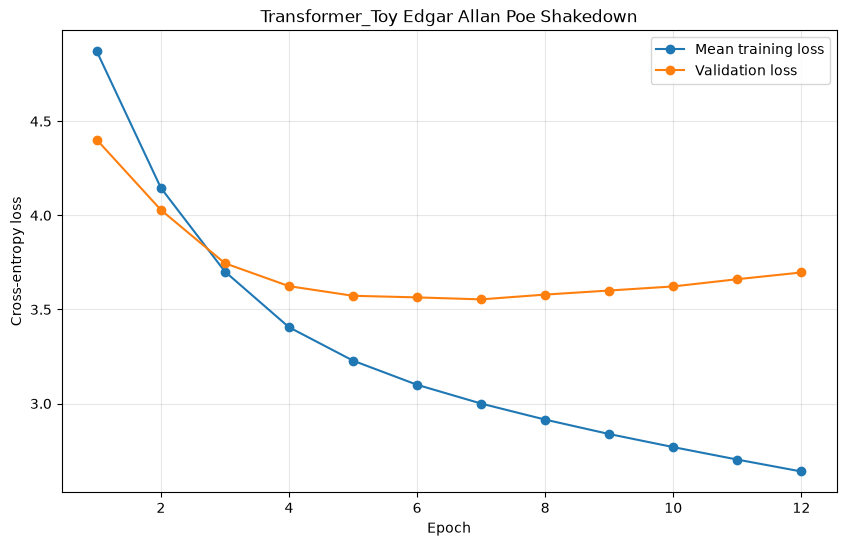

In [12]:
train_losses = np.asarray(history.train_losses, dtype=np.float32)
validation_losses = np.asarray(history.validation_losses, dtype=np.float32)
steps_per_epoch = len(train_batches)

epoch_train_losses = np.array(
    [
        train_losses[index:index + steps_per_epoch].mean()
        for index in range(0, len(train_losses), steps_per_epoch)
    ],
    dtype=np.float32,
)

plt.figure(figsize=(10, 6))
plt.plot(
    np.arange(1, len(epoch_train_losses) + 1),
    epoch_train_losses,
    marker="o",
    label="Mean training loss",
)
plt.plot(
    np.arange(1, len(validation_losses) + 1),
    validation_losses,
    marker="o",
    label="Validation loss",
)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Transformer_Toy Edgar Allan Poe Shakedown")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 10. Review generation snapshots

In [13]:
if not generation_callback.snapshots:
    print("No generation snapshots were captured.")
else:
    for snapshot in generation_callback.snapshots:
        print("\n" + "=" * 60)
        print(f"Generation snapshot — epoch {snapshot.epoch}")
        print("=" * 60)
        print(snapshot.text)


Generation snapshot — epoch 5
Once upon my bow—for the whirl.]

I began I am I saw waste balls not who not see me myours for the spot of the cene hont of voice of the water of the Ben-Bon-Bon-Bob, Stastley surprisoned—the book; but for the interiors were letter was one much was interrupted to their down, of mere is I am to drown some portion of the kisland word a little of the willow, but these things which a rushed in scountuously trivial words are before the scalp fancy, and it is wif which was taken with a barken chanc, of the table, he strictly saw, in great into the physiane-Hop-Bon-Bonesquerts St. Perhaman bete came waterie burning, found, of its city of Baron of Bandemarg’s D

Generation snapshot — epoch 10
Once upon my neglecle up my fistene to here. I found represented it. The meditor of the water had been grave us like a large land, in a well I breathed to a distressated candle of the bed. After superily imagined into the houset of any pertent vales, by falling in a fair and

## 11. Load the best checkpoint and generate

In [14]:
best_path = Path(best_checkpoint.best_checkpoint_path)

if not best_path.exists():
    raise FileNotFoundError(f"Best checkpoint was not created: {best_path}")

loaded_metadata = tt.CheckpointMetadata()
loaded_history = tt.TrainingHistory()

tt.Checkpoint.load(
    path=str(best_path),
    parameters=model.parameters(),
    metadata=loaded_metadata,
    history=loaded_history,
)

print("Loaded:", loaded_metadata)

final_generation_config = tt.GenerationConfig()
final_generation_config.max_new_tokens = 500
final_generation_config.temperature = GENERATION_TEMPERATURE
final_generation_config.top_k = min(GENERATION_TOP_K, train_dataset.vocab_size)
final_generation_config.greedy_sampling = False
final_generation_config.print_generated_text = True
final_generation_config.print_token_ids = False
final_generation_config.random_seed = GENERATION_SEED + 1
final_generation_config.validate()

final_text = model.generate(
    prompt=GENERATION_PROMPT,
    tokenizer=tokenizer,
    config=final_generation_config,
    rng=tt.Random(GENERATION_SEED + 1),
)

print("\n" + "=" * 60)
print("Best-checkpoint generation")
print("=" * 60)
print(final_text)
print("=" * 60)

Loaded: CheckpointMetadata(epoch=7, global_step=5124, run_name='eap_bpe_512_python_shakedown')

Best-checkpoint generation
Once upontake was advitive painting the corner, and full dignity, he said, to look my imbrace might not well him for a huge appreciated and like with a certain returns, he was of course, shall not got up in a hour or deceased of which he said; I v’t heard my laughter. Et swelf-one of Morday, I could not regarded the hount stone of bring his row—a far as down, is on the most cases of it. Thesitation. Puttorian he swallow his own tendence, with the infancy of the consideration came whalf than there was a most keep for far up from the corpse and portraves.

In say, it is spoke your genius. In supposed, and made to his spiritual of an instancy when which, for some people case mout, I had been conceived supposed to gained it from the volvality of these who what he left hurily conveyed.

“In this is made spirit was a case—not well admittous regulfire; and three was a goo

## 12. Save history

In [15]:
history_path = ARTIFACT_ROOT / "training_history.csv"
history.save_csv(str(history_path))

print("History:", history_path)
print("Tokenizer:", TOKENIZER_PATH)
print("Checkpoints:", CHECKPOINT_DIR)

History: c:\Users\Alexander\OneDrive\Transformers_Toy\python_shakedown_artifacts\eap_bpe_512\training_history.csv
Tokenizer: c:\Users\Alexander\OneDrive\Transformers_Toy\python_shakedown_artifacts\eap_bpe_512\tokenizers\eap_bpe_512.bin
Checkpoints: c:\Users\Alexander\OneDrive\Transformers_Toy\python_shakedown_artifacts\eap_bpe_512\checkpoints


## Current limitations

- Dropout fields are set to zero because dropout and train/eval mode switching are planned for the next architectural milestone.
- Checkpoints restore model parameters, gradients, metadata, and history, but not Adam moment state.
- Batches are materialized before training to match the current native `Trainer` interface and make the run reproducible.